# Homework 2

# Part 2: Numerical

Lotka-Volterra predator-prey model:

\begin{align}

&\frac{dx}{dt} = \alpha x - \beta xy, \\

&\frac{dy}{dt} = \delta xy - \gamma y,

\end{align}

where $x$ - population of hare (in thousands), $y$ - population of lynx (in thousands), and $\alpha, \beta, \gamma, \delta > 0$.

# 2.1 Synthetic Data 

# a) Generate data 

\begin{align}

&\alpha = 0.6, \beta = 0.025, \delta = 0.0125, \gamma = 0.5 \\

& x(0) = 30, y(0) = 4

\end{align}


System simulated for $t = 0,1,...,90$.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt 
import torch as tc
import torch.nn as nn

Running code on GPU (CUDA or MPS - for MacOS)

In [2]:
#Check for using GPU on MacOS (No CUDA for MacOS)
print(tc.backends.mps.is_available())
device = tc.device("mps" if tc.backends.mps.is_available() else "cpu")

#For using CUDA, e.g., on Symmetry, comment the above and run the below instead
#device = 'cuda' if tc.cuda.is_available() else 'cpu'

True


Solve the system of differenatial equations and plot the results

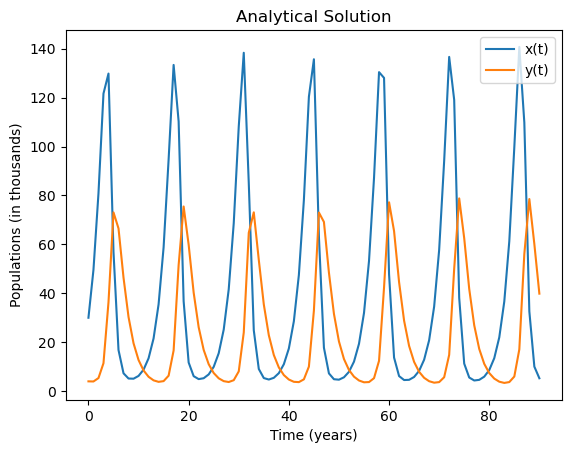

In [ ]:
#Solving the system of differential equations

#Parameters
a = 0.6
b = 0.025
d = 0.0125
g = 0.5

#Initail conditions
x0 = 30
y0 = 4

#Time points to evaluate
t_eval = np.linspace(0, 90, 91)
t_span = (0,90)

#Define system of first order differential equations
def populations_ODEs(t, v):
    """
    t - time array 
    v = (x,y) - vector of x and y values
    """
    x, y = v

    dxdt = a*x - b*x*y
    dydt = d*x*y - g*y

    return np.array([dxdt, dydt], dtype=float)

#Solving
sol = solve_ivp(populations_ODEs, t_span, [x0, y0], t_eval=t_eval)



#Accesing the data for plot 
x_data = sol.y[0]
y_data = sol.y[1]


# Plot
fig, ax = plt.subplots()
ax.plot(t_eval, x_data, label="x(t)")
ax.plot(t_eval, y_data, label="y(t)")

ax.set_title("Analytical Solution")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Populations (in thousands)")
ax.legend()

fig.savefig("analytical_solution.png")
plt.show()


Below, solving for more data points for point d)

In [4]:
#Time points to evaluate
t_eval_2 = np.linspace(0, 90, 300)

#Solving for more points
sol_2 = solve_ivp(populations_ODEs, t_span, [x0, y0], t_eval = t_eval_2)

# b) Approximate time derivatives using central differences

\begin{align}

&\dot{x}(t_i) \approx \frac{x_{i+1}-x_{i-1}}{2\Delta t}\\

&\dot{y}(t_i) \approx \frac{y_{i+1}-y_{i-1}}{2\Delta t}\\

\end{align}

In [5]:
#Approximating derivatives

dx_approx = np.zeros(len(t_eval))
dy_approx = np.zeros(len(t_eval))

for k in range(len(t_eval)):
    if k != 0 and k < (len(t_eval) -1):
        dx_approx[k] = (x_data[k+1] - x_data[k-1])/2
        dy_approx[k] = (y_data[k+1] - y_data[k-1])/2

#First value repeated 
dx_approx[0] = dx_approx[1]
dy_approx[0] = dy_approx[1]

#Last value repeated
dx_approx[-1] = dx_approx[-2]
dy_approx[-1] = dy_approx[-2]

#Check
#print(dx_approx)
#print(dy_approx)

# c) Estimating the parameters using linear regression

We define:

\begin{equation}

\omega^T = [\alpha, \beta, \gamma, \delta].

\end{equation}

The system becomes:

\begin{equation}

\frac{d}{dt} 
\begin{bmatrix} x \\ y \end{bmatrix}
=
\begin{bmatrix} x & -xy & 0 & 0 \\ 0 & 0 & -y & xy \end{bmatrix} \omega = A(x,y) \omega,


\end{equation}

where 

\begin{equation}

A(x,y) \equiv
\begin{bmatrix} x & -xy & 0 & 0 \\ 0 & 0 & -y & xy \end{bmatrix}.

\end{equation}

To build a regression system, we need to stack all of the points:

\begin{equation}

\begin{bmatrix}
x_2  &- x_2 y_2 & 0 & 0 \\
0 & 0 & -y_2 & x_2 y_2 \\
\vdots & & & \vdots \\
x_{N-1} & - x_{N-1} y_{N-1} & 0 & 0 \\
0 & 0 & -y_{N-1} & x_{N-1} y_{N-1} 
\end{bmatrix}


\begin{bmatrix}
\alpha \\ \beta \\ \gamma \\ \delta
\end{bmatrix}
=
\begin{bmatrix}
\dot{x}_2 \\ \dot{y}_2 \\ \vdots \\ \dot{x}_{N-1} \\ \dot{y}_{N-1}
\end{bmatrix}.

\end{equation}

This is $A(x,y)\omega = b$ and the solution is:


\begin{equation}
\omega^* = (A^\top A)^{-1} A^\top b.
\end{equation}

In [6]:
#Trunckating all data

dx_lin_reg = dx_approx[1:-1]
dy_lin_reg = dy_approx[1:-1]
x_lin_reg = x_data[1:-1]
y_lin_reg = y_data[1:-1]


#Defining b vector

b = np.zeros(2*(len(dx_lin_reg)))

#even and odd counts
k_even = 0 
k_odd = 0 

for k in range(len(b)):
    if k % 2 == 0:
        b[k] = dx_approx[k_even]
        k_even += 1
    if k % 2 != 0:
        b[k] = dy_approx[k_odd]
        k_odd += 1

b_transpose = b.reshape(-1,1)

#Check
#print(b_transpose)

In [7]:
#Defining matrix A

A = np.zeros((2*(len(dx_lin_reg)),4))

#even and odd counts
i_even = 0 
i_odd = 0 

for i in range(2*(len(dx_lin_reg))):
    if i % 2 == 0:
        A[i,0] = x_lin_reg[i_even]
        A[i,1] = -1*x_lin_reg[i_even]*y_lin_reg[i_even]
        i_even += 1
    if i % 2 != 0:
        A[i,2] = - y_lin_reg[i_odd]
        A[i,3] = x_lin_reg[i_odd]*y_lin_reg[i_odd]
        i_odd += 1

#Check
#print(A)

In [8]:
#Solving the linear regression equations to get the parameters

A_transpose = A.T
w_lin_reg = ( np.linalg.inv(A_transpose@A) @ A_transpose @ b_transpose )

print('The parameters found with linear regression are:')
print(f'a ={w_lin_reg[0]}')
print(f'b ={w_lin_reg[1]}')
print(f'g ={w_lin_reg[2]}')
print(f'd ={w_lin_reg[3]}')

The parameters found with linear regression are:
a =[0.45417067]
b =[0.01151109]
g =[0.05753484]
d =[0.00564007]


The parameters found with linear regression are quite off compared to the real ones, especially parameters b ($\beta$) and d ($\delta$), which differ by about 50% of their value.

### Plotting with real and estimated numbers for comparison

In [9]:
#Solving the differential equation with the coefficients found with linear regression

#Solving the system of differential equations

#Parameters
a_lr = w_lin_reg[0,0]
b_lr= w_lin_reg[1,0]
d_lr = w_lin_reg[3,0]
g_lr = w_lin_reg[2,0]

#Initail conditions
x0 = 30
y0 = 4

#Time points to evaluate
t_eval = np.linspace(0, 90, 91)
t_span = (0,90)

#Define system of first order differential equations
def populations_ODEs_lr(t, v):
    """
    t - time array 
    v = (x,y) - vector of x and y values
    """
    x, y = v

    dxdt = a_lr*x - b_lr*x*y
    dydt = d_lr*x*y - g_lr*y

    return [dxdt, dydt]

#Solving
sol_lr = solve_ivp(populations_ODEs_lr, t_span, [x0, y0], t_eval=t_eval)

#Accessing the data for later use
#t_tc=tc.from_numpy(sol_lr.t).unsqueeze(1).float()
#x_tc=tc.from_numpy(sol_lr.y[0]).unsqueeze(1).float()
#y_tc=tc.from_numpy(sol_lr.y[1]).unsqueeze(1).float()

#Accesing the data for plot 
x_data_lr = sol_lr.y[0]
y_data_lr = sol_lr.y[1]


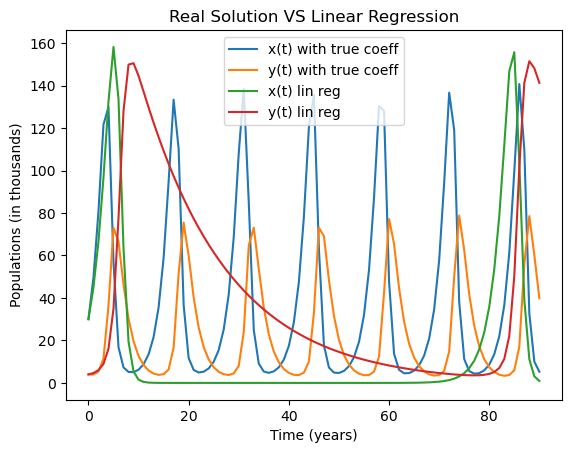

In [10]:
# Plot
fig, ax = plt.subplots()
ax.plot(t_eval, x_data, label="x(t) with true coeff")
ax.plot(t_eval, y_data, label="y(t) with true coeff")
ax.plot(t_eval, x_data_lr, label="x(t) lin reg")
ax.plot(t_eval, y_data_lr, label="y(t) lin reg")

ax.set_title("Real Solution VS Linear Regression")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Populations (in thousands)")
ax.legend()

fig.savefig("Linear_regression.png")
plt.show()

We find a large discrepancy for the simulation with the coefficients found with linear regression.

# d) Linear regression with more data points

COMMENT: Sometimes I needed to restart kernel to run solve_ivp for more points, because my jupyter notebook was probably storing the previous values.

In [11]:

#Accesing the data for plot from before (end of part a)
x_data_2 = sol_2.y[0]
y_data_2 = sol_2.y[1]


#Approximating more derivative points
dx_approx_2 = np.zeros(len(t_eval_2))
dy_approx_2 = np.zeros(len(t_eval_2))

for k in range(len(t_eval_2)):
    if k != 0 and k < (len(t_eval_2) -1):
        dx_approx_2[k] = (x_data_2[k+1] - x_data_2[k-1])/2
        dy_approx_2[k] = (y_data_2[k+1] - y_data_2[k-1])/2

#First value repeated 
dx_approx_2[0] = dx_approx_2[1]
dy_approx_2[0] = dy_approx_2[1]

#Last value repeated
dx_approx_2[-1] = dx_approx_2[-2]
dy_approx_2[-1] = dy_approx_2[-2]

#Trunckating all data
dx_lin_reg_2 = dx_approx_2[1:-1]
dy_lin_reg_2 = dy_approx_2[1:-1]
x_lin_reg_2 = x_data_2[1:-1]
y_lin_reg_2 = y_data_2[1:-1]


#Defining b vector
b_2 = np.zeros(2*(len(dx_lin_reg_2)))

#even and odd counts
k_even_2 = 0 
k_odd_2 = 0 

for k in range(len(b_2)):
    if k % 2 == 0:
        b_2[k] = dx_approx_2[k_even_2]
        k_even_2 += 1
    if k % 2 != 0:
        b_2[k] = dy_approx_2[k_odd_2]
        k_odd_2 += 1

b_transpose_2 = b_2.reshape(-1,1)

A_2 = np.zeros((2*(len(dx_lin_reg_2)),4))

#even and odd counts
i_even_2 = 0 
i_odd_2 = 0 

for i in range(2*(len(dx_lin_reg_2))):
    if i % 2 == 0:
        A_2[i,0] = x_lin_reg_2[i_even_2]
        A_2[i,1] = -1*x_lin_reg_2[i_even_2]*y_lin_reg_2[i_even_2]
        i_even_2 += 1
    if i % 2 != 0:
        A_2[i,2] = - y_lin_reg_2[i_odd_2]
        A_2[i,3] = x_lin_reg_2[i_odd_2]*y_lin_reg_2[i_odd_2]
        i_odd_2 += 1

A_transpose_2 = A_2.T
w_lin_reg_2 = ( np.linalg.inv(A_transpose_2@A_2) @ A_transpose_2 @ b_transpose_2 )

print('The parameters found with linear regression with more points are:')
print(f'a ={w_lin_reg_2[0]}')
print(f'b ={w_lin_reg_2[1]}')
print(f'g ={w_lin_reg_2[2]}')
print(f'd ={w_lin_reg_2[3]}')

The parameters found with linear regression with more points are:
a =[0.18824934]
b =[0.00691449]
g =[0.11762508]
d =[0.00345052]


In [12]:
#Solving the differential equation with the coefficients found with linear regression

#Solving the system of differential equations

#Parameters
a_lr_2 = w_lin_reg_2[0,0]
b_lr_2= w_lin_reg_2[1,0]
d_lr_2 = w_lin_reg_2[3,0]
g_lr_2 = w_lin_reg_2[2,0]

#Initail conditions
x0 = 30
y0 = 4


#Define system of first order differential equations
def populations_ODEs_lr_2(t, v):
    """
    t - time array 
    v = (x,y) - vector of x and y values
    """
    x, y = v

    dxdt = a_lr_2*x - b_lr_2*x*y
    dydt = d_lr_2*x*y - g_lr_2*y

    return [dxdt, dydt]

#Solving
sol_lr_2 = solve_ivp(populations_ODEs_lr_2, t_span, [x0, y0], t_eval=t_eval_2)

#Accessing the data for later use
#t_tc=tc.from_numpy(sol_lr.t).unsqueeze(1).float()
#x_tc=tc.from_numpy(sol_lr.y[0]).unsqueeze(1).float()
#y_tc=tc.from_numpy(sol_lr.y[1]).unsqueeze(1).float()

#Accesing the data for plot 
x_data_lr_2 = sol_lr_2.y[0]
y_data_lr_2 = sol_lr_2.y[1]

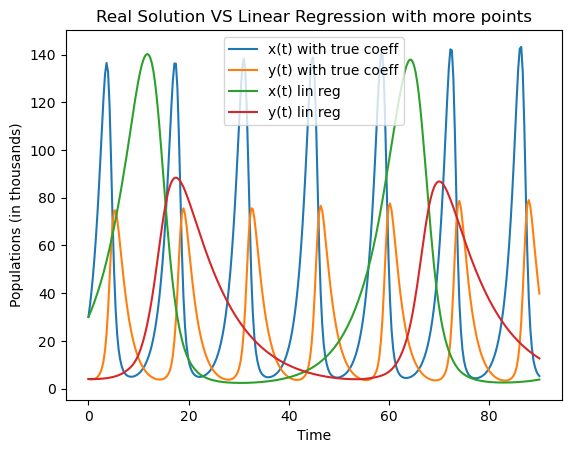

In [13]:
# Plot
fig, ax = plt.subplots()
ax.plot(t_eval_2, x_data_2, label="x(t) with true coeff")
ax.plot(t_eval_2, y_data_2, label="y(t) with true coeff")
ax.plot(t_eval_2, x_data_lr_2, label="x(t) lin reg")
ax.plot(t_eval_2, y_data_lr_2, label="y(t) lin reg")

ax.set_title("Real Solution VS Linear Regression with more points")
ax.set_xlabel("Time")
ax.set_ylabel("Populations (in thousands)")
ax.legend()

fig.savefig("Linear_regression_more_point.png")
plt.show()

Running the linear regression with more data points we get the coefficients $\alpha, \beta, \gamma, \delta$ that are way more off then before, but we get more periods on the graph. Nevertheless, for more data points, linear regression performs much worse. Linear regression gives relatively good result for the beginnig and end of the time interval (see plot with the original amount of points).

# 2.2 Hudson’s Bay Lynx-Hare Data

# a) Loading the data sets

In [14]:
import pandas as pd

In [15]:
#Loading two data sets

data_set1 = pd.read_csv("Leigh1968_harelynx.csv")

data_set2 = pd.read_csv("lotvol.csv")

Plotting the time series

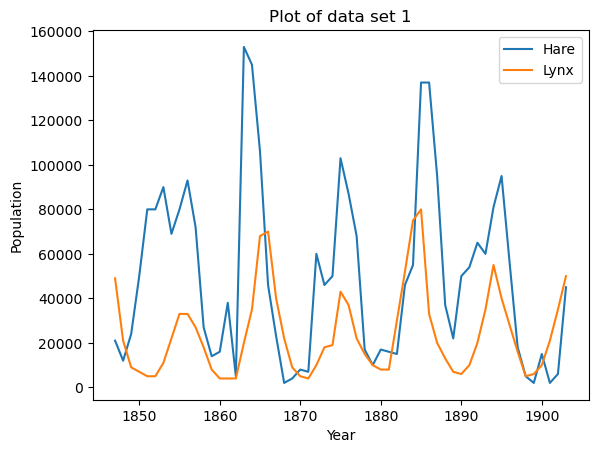

In [18]:
#Plot data set 1

fig, ax = plt.subplots()

ax.plot(data_set1["year"], data_set1["hare"], label="Hare")
ax.plot(data_set1["year"], data_set1["lynx"], label="Lynx")

ax.set_title("Plot of data set 1")
ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.legend()

fig.savefig("Plot_data_set1.png")
plt.show()

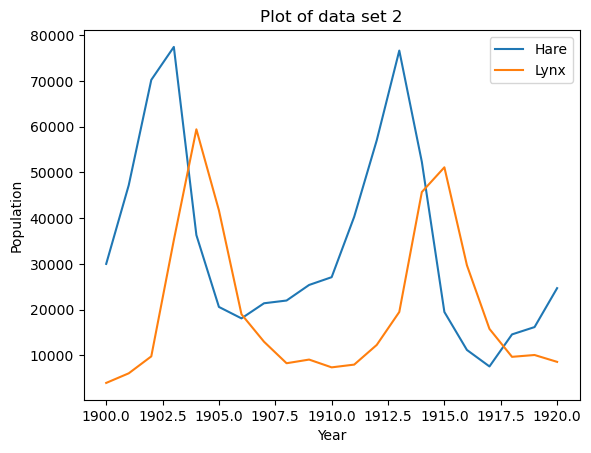

In [19]:
#Plot data set 2

fig, ax = plt.subplots()

ax.plot(data_set2["year"], data_set2["hare"], label="Hare")
ax.plot(data_set2["year"], data_set2["lynx"], label="Lynx")

ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.legend()

ax.set_title("Plot of data set 2")
fig.savefig("Plot_data_set2.png")
plt.show()

# b) Approximating time derivatives using central differences

## DATA SET 1

In [20]:
#Accessing the numerical values

t_data_ds1 = data_set1["year"].values
x_data_ds1 = data_set1["hare"].values
y_data_ds1 = data_set1["lynx"].values

dx_approx_ds1 = np.zeros(len(t_data_ds1))
dy_approx_ds1 = np.zeros(len(t_data_ds1))

for k in range(len(t_data_ds1)):
    if k != 0 and k < (len(t_data_ds1) -1):
        dx_approx_ds1[k] = (x_data_ds1[k+1] - x_data_ds1[k-1])/2
        dy_approx_ds1[k] = (y_data_ds1[k+1] - y_data_ds1[k-1])/2

#First value repeated 
dx_approx_ds1[0] = dx_approx_ds1[1]
dy_approx_ds1[0] = dy_approx_ds1[1]

#Last value repeated
dx_approx_ds1[-1] = dx_approx_ds1[-2]
dy_approx_ds1[-1] = dy_approx_ds1[-2]

## DATA SET 2

In [21]:
#Accessing the numerical values

t_data_ds2 = data_set2["year"].values
x_data_ds2 = data_set2["hare"].values
y_data_ds2 = data_set2["lynx"].values

dx_approx_ds2 = np.zeros(len(t_data_ds2))
dy_approx_ds2 = np.zeros(len(t_data_ds2))

for k in range(len(t_data_ds2)):
    if k != 0 and k < (len(t_data_ds2) -1):
        dx_approx_ds2[k] = (x_data_ds2[k+1] - x_data_ds2[k-1])/2
        dy_approx_ds2[k] = (y_data_ds2[k+1] - y_data_ds2[k-1])/2

#First value repeated 
dx_approx_ds2[0] = dx_approx_ds2[1]
dy_approx_ds2[0] = dy_approx_ds2[1]

#Last value repeated
dx_approx_ds2[-1] = dx_approx_ds2[-2]
dy_approx_ds2[-1] = dy_approx_ds2[-2]

# c) Constructing regression matrices and estimating parameters using linear regression

In [24]:
# Defining function to output the parameters of linear regression

def parameter_matrix(dx_approx,dy_approx,x_data,y_data):
    """ 
    Function calculating parameters a,b,g,d using linear regression. 
    """
    #Trunckating all data
    dx_lin_reg = dx_approx[1:-1]
    dy_lin_reg = dy_approx[1:-1]
    x_lin_reg = x_data[1:-1]
    y_lin_reg = y_data[1:-1]


    #Defining b vector

    b = np.zeros(2*(len(dx_lin_reg)))

    #even and odd counts
    k_even = 0 
    k_odd = 0 

    for k in range(len(b)):
        if k % 2 == 0:
            b[k] = dx_approx[k_even]
            k_even += 1
        if k % 2 != 0:
            b[k] = dy_approx[k_odd]
            k_odd += 1

    b_transpose = b.reshape(-1,1)

    A = np.zeros((2*(len(dx_lin_reg)),4))

    #even and odd counts
    i_even = 0 
    i_odd = 0 

    for i in range(2*(len(dx_lin_reg))):
        if i % 2 == 0:
            A[i,0] = x_lin_reg[i_even]
            A[i,1] = -1*x_lin_reg[i_even]*y_lin_reg[i_even]
            i_even += 1
        if i % 2 != 0:
            A[i,2] = - y_lin_reg[i_odd]
            A[i,3] = x_lin_reg[i_odd]*y_lin_reg[i_odd]
            i_odd += 1
    
    A_transpose = A.T
    w_lin_reg = ( np.linalg.inv(A_transpose@A) @ A_transpose @ b_transpose )

    a_lr = w_lin_reg[0,0]
    b_lr= w_lin_reg[1,0]
    d_lr = w_lin_reg[3,0]
    g_lr = w_lin_reg[2,0]

    return np.array([a_lr,b_lr,d_lr,g_lr])

## DATA SET 1

In [26]:
parms1 = parameter_matrix(dx_approx_ds1,dy_approx_ds1,x_data_ds1,y_data_ds1)

print("Coefficients a,b,g,d for data set 1 are:")
print(parms1)

Coefficients a,b,g,d for data set 1 are:
[ 1.32226013e-01 -4.27199703e-07  1.73254723e-06 -1.09702136e-02]


## DATA SET 2

In [27]:
parms2 = parameter_matrix(dx_approx_ds2,dy_approx_ds2,x_data_ds2,y_data_ds2)

print("Coefficients a,b,g,d for data set 2 are:")
print(parms2)

Coefficients a,b,g,d for data set 2 are:
[4.07387197e-01 1.26025700e-05 9.40876585e-06 1.49734922e-01]


# d) Simulate the Lotka-Volterra system using the estimated parameters and compare with the historical data (for both datasets).

In [28]:
#Function to simulate the system given the parameters - solving the system of ODEs


def simulation(parms,x0,y0,t_data):
    """ 
    Function to simulate the system given the parameters - solving the system of ODEs given a,b,g.d
    """
    #Parameters
    a_lr = parms[0]
    b_lr= parms[1]
    d_lr = parms[3]
    g_lr = parms[2]

    #Time points to evaluate
    t_eval = t_data
    t_span = (t_data[0],t_data[-1])

    #Define system of first order differential equations
    def populations_ODEs_lr(t, v):
        """
        t - time array 
        v = (x,y) - vector of x and y values
        """
        x, y = v

        dxdt = a_lr*x - b_lr*x*y
        dydt = d_lr*x*y - g_lr*y

        return [dxdt, dydt]

    #Solving
    sol_lr = solve_ivp(populations_ODEs_lr, t_span, [x0, y0], t_eval=t_eval)

    #Accesing the data 
    x_data_lr = sol_lr.y[0]
    y_data_lr = sol_lr.y[1]

    return [x_data_lr,y_data_lr]

## DATA SET 1

In [33]:
x0_ds1 = x_data_ds1[0]
y0_ds1 = y_data_ds1[0]

x_plot_ds1, y_plot_ds1 = simulation(parms1,x0_ds1,y0_ds1,t_data_ds1)

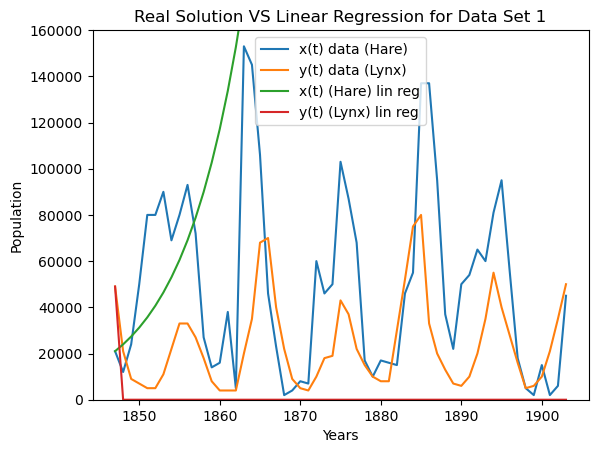

In [42]:
#Plot 

fig, ax = plt.subplots()
ax.plot(t_data_ds1, x_data_ds1, label="x(t) data (Hare)")
ax.plot(t_data_ds1, y_data_ds1, label="y(t) data (Lynx)")
ax.plot(t_data_ds1, x_plot_ds1, label="x(t) (Hare) lin reg")
ax.plot(t_data_ds1, y_plot_ds1, label="y(t) (Lynx) lin reg")

ax.set_title("Real Solution VS Linear Regression for Data Set 1")
ax.set_xlabel("Years")
ax.set_ylabel("Population")
ax.set_ylim(0, 160000)  
ax.legend()

fig.savefig("Linear_regression_data_set1.png")
plt.show()

## DATA SET 2

In [37]:
x0_ds2 = x_data_ds2[0]
y0_ds2 = y_data_ds2[0]

x_plot_ds2, y_plot_ds2 = simulation(parms2,x0_ds2,y0_ds2,t_data_ds2)

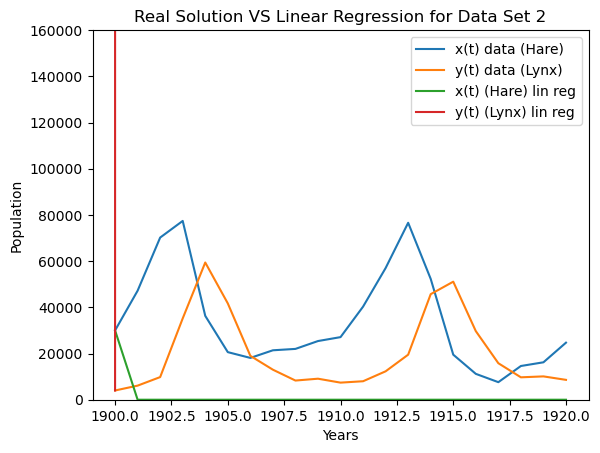

In [41]:
#Plot 

fig, ax = plt.subplots()
ax.plot(t_data_ds2, x_data_ds2, label="x(t) data (Hare)")
ax.plot(t_data_ds2, y_data_ds2, label="y(t) data (Lynx)")
ax.plot(t_data_ds2, x_plot_ds2, label="x(t) (Hare) lin reg")
ax.plot(t_data_ds2, y_plot_ds2, label="y(t) (Lynx) lin reg")

ax.set_title("Real Solution VS Linear Regression for Data Set 2")
ax.set_xlabel("Years")
ax.set_ylabel("Population")
ax.set_ylim(0, 160000)  
ax.legend()

fig.savefig("Linear_regression_data_set2.png")
plt.show()

Linear regression preforms extremelly bad for both data sets.

# 2.3 NN and PINN

# a) Neural Network 

We expect the neural network to perform much better than the liner regression. NN can capture the non-linearity in the data.

## SYNTHETIC DATA

In [43]:
#Accessing the data

t_syn=tc.from_numpy(sol.t).unsqueeze(1).float()
x_syn=tc.from_numpy(sol.y[0]).unsqueeze(1).float()
y_syn=tc.from_numpy(sol.y[1]).unsqueeze(1).float()

#Normalizing the data
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

t_syn_n = normalize(t_syn)
x_syn_n = normalize(x_syn)
y_syn_n = normalize(y_syn)

#Time based split of the data into training and test set
def split(t, x, y, split_ratio=0.7):
    n = int(len(t) * split_ratio)
    return (t[:n], x[:n], y[:n], t[n:], x[n:], y[n:])

#Train/test split
tS_tr, xS_tr, yS_tr, tS_te, xS_te, yS_te = split(t_syn_n, x_syn_n, y_syn_n)



## HISTORICAL DATA

In [44]:
#Accessing the data

t_real_1 = tc.tensor(data_set1["year"].values, dtype=tc.float32).view(-1, 1)
x_real_1 = tc.tensor(data_set1["hare"].values, dtype=tc.float32).view(-1, 1)
y_real_1= tc.tensor(data_set1["lynx"].values, dtype=tc.float32).view(-1, 1)

t_real_2 = tc.tensor(data_set2["year"].values, dtype=tc.float32).view(-1, 1)
x_real_2 = tc.tensor(data_set2["hare"].values, dtype=tc.float32).view(-1, 1)
y_real_2= tc.tensor(data_set2["lynx"].values, dtype=tc.float32).view(-1, 1)

#Normalizing the data

t_real_1_n = normalize(t_real_1)
x_real_1_n = normalize(x_real_1)
y_real_1_n = normalize(y_real_1)

t_real_2_n = normalize(t_real_2)
x_real_2_n = normalize(x_real_2)
y_real_2_n = normalize(y_real_2)

#Train/test split
tR1_tr, xR1_tr, yR1_tr, tR1_te, xR1_te, yR1_te = split(t_real_1_n, x_real_1_n, y_real_1_n)

tR2_tr, xR2_tr, yR2_tr, tR2_te, xR2_te, yR2_te = split(t_real_2_n, x_real_2_n, y_real_2_n)

In [45]:
#Combinig the sets for training

t_train = tc.cat([tS_tr,tR1_tr,tR2_tr], dim=0)
y_train = tc.cat([tc.cat([xS_tr, yS_tr], dim=1), tc.cat([xR1_tr, yR1_tr], dim=1), tc.cat([xR2_tr, yR2_tr], dim=1)], dim=0)


#Separate evaluation 

test_syn = (tS_te, tc.cat([xS_te, yS_te], dim=1))

test_real_1 = (tR1_te,tc.cat([xR1_te, yR1_te], dim=1))

test_real_2 = (tR2_te,tc.cat([xR2_te, yR2_te], dim=1))

## NN Population Model

In [50]:
#Defining the model in analogous way to code from tutorial 3

class PopNet(nn.Module):
    def __init__(self, neurons, M, output=2, activation=nn.Tanh()):
        """
        neurons: number of neurons per hidden layer
        M: number of hidden layers
        output: 2 (hare, lynx)
        activation: activation function
        """
        super(PopNet, self).__init__()

        self.neurons = neurons
        self.M = M
        self.output = output

        # Hidden layers
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(1, neurons)]
        )
        self.hidden_layers.extend(
            [nn.Linear(neurons, neurons) for _ in range(M - 1)]
        )

        # Output layer
        self.output_layer = nn.Linear(neurons, output)

        # Activation
        self.activation = activation

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)
        return x

In [53]:
#Training the model 

model = PopNet(neurons=64,M=3,activation=nn.Tanh())
criterion = nn.MSELoss(reduction="sum")
optimizer = tc.optim.Adam(model.parameters(), lr=1e-3)

epochs = 2000

for epoch in range(epochs):
    model.train()

    pred = model(t_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 39.7851
Epoch 50, Loss: 21.2119
Epoch 100, Loss: 21.1696
Epoch 150, Loss: 21.1597
Epoch 200, Loss: 21.1477
Epoch 250, Loss: 21.1316
Epoch 300, Loss: 21.1083
Epoch 350, Loss: 21.0722
Epoch 400, Loss: 21.0183
Epoch 450, Loss: 20.9770
Epoch 500, Loss: 20.9314
Epoch 550, Loss: 20.8737
Epoch 600, Loss: 20.7823
Epoch 650, Loss: 20.5894
Epoch 700, Loss: 20.3439
Epoch 750, Loss: 20.1699
Epoch 800, Loss: 20.1133
Epoch 850, Loss: 20.0044
Epoch 900, Loss: 19.9498
Epoch 950, Loss: 19.9216
Epoch 1000, Loss: 19.8717
Epoch 1050, Loss: 19.8283
Epoch 1100, Loss: 19.7836
Epoch 1150, Loss: 19.8037
Epoch 1200, Loss: 19.7108
Epoch 1250, Loss: 19.6698
Epoch 1300, Loss: 19.6274
Epoch 1350, Loss: 19.5837
Epoch 1400, Loss: 20.4182
Epoch 1450, Loss: 19.5179
Epoch 1500, Loss: 19.4808
Epoch 1550, Loss: 19.4452
Epoch 1600, Loss: 19.4110
Epoch 1650, Loss: 19.3783
Epoch 1700, Loss: 19.3474
Epoch 1750, Loss: 19.3183
Epoch 1800, Loss: 19.2910
Epoch 1850, Loss: 19.2699
Epoch 1900, Loss: 19.2463
Epoch 195

## RESULTS

In [54]:
#Evaluating the model on the test data


#Defining the function performing the evaluation 
def evaluate(t, y_true):
    model.eval()
    with tc.no_grad():
        y_pred = model(t)
    return y_pred, y_true


#Evakuating each of the synthetic data set, data set 1, data set 2
pred_syn, true_syn = evaluate(*test_syn)
pred_real_1, true_real_1 = evaluate(*test_real_1)
pred_real_2, true_real_2 = evaluate(*test_real_2)

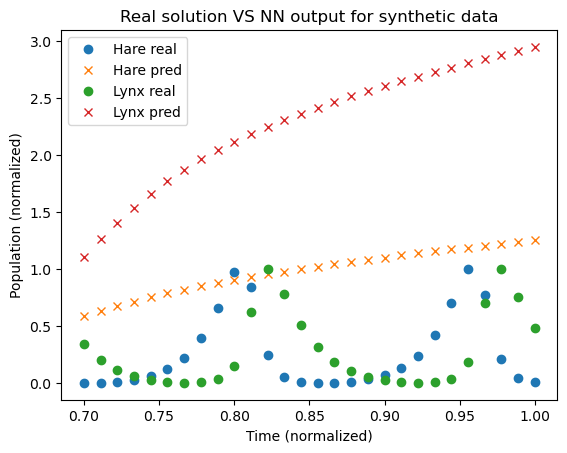

In [62]:
#Poltting the results for synthetic data

fig, ax = plt.subplots()

ax.plot(test_syn[0], true_syn[:,0], "o", label="Hare real")
ax.plot(test_syn[0], pred_syn[:,0], "x", label="Hare pred")

ax.plot(test_syn[0], true_syn[:,1], "o", label="Lynx real")
ax.plot(test_syn[0], pred_syn[:,1], "x", label="Lynx pred")

ax.set_title("Real solution VS NN output for synthetic data")
ax.set_xlabel("Time (normalized)")
ax.set_ylabel("Population (normalized)")

ax.legend()

fig.savefig("NN_synthetic_data.png")
plt.show()

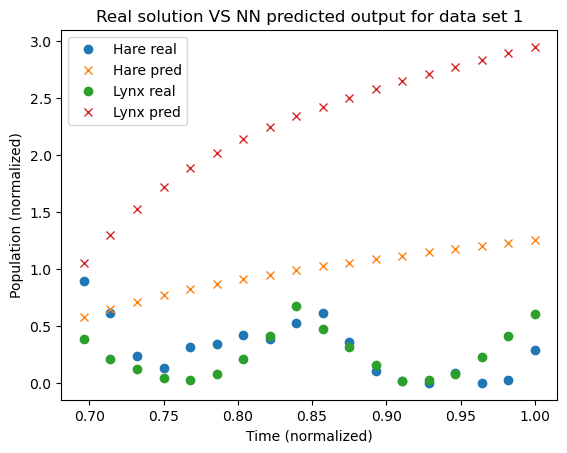

In [63]:
#Poltting the results for data set 1

fig, ax = plt.subplots()

ax.plot(test_real_1[0], true_real_1[:,0], "o", label="Hare real")
ax.plot(test_real_1[0], pred_real_1[:,0], "x", label="Hare pred")

ax.plot(test_real_1[0], true_real_1[:,1], "o", label="Lynx real")
ax.plot(test_real_1[0], pred_real_1[:,1], "x", label="Lynx pred")

ax.set_title("Real solution VS NN predicted output for data set 1")
ax.set_xlabel("Time (normalized)")
ax.set_ylabel("Population (normalized)")

ax.legend()

fig.savefig("NN_data_set1.png")
plt.show()

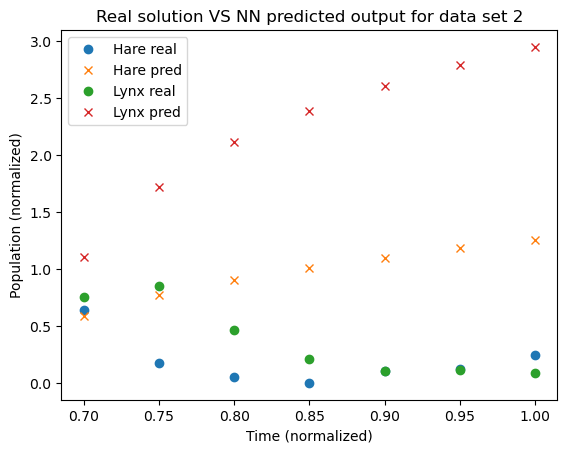

In [64]:
#Poltting the results for data set 2

fig, ax = plt.subplots()

ax.plot(test_real_2[0], true_real_2[:,0], "o", label="Hare real")
ax.plot(test_real_2[0], pred_real_2[:,0], "x", label="Hare pred")

ax.plot(test_real_2[0], true_real_2[:,1], "o", label="Lynx real")
ax.plot(test_real_2[0], pred_real_2[:,1], "x", label="Lynx pred")

ax.set_title("Real solution VS NN predicted output for data set 2")
ax.set_xlabel("Time (normalized)")
ax.set_ylabel("Population (normalized)")

ax.legend()

fig.savefig("NN_data_set2.png")
plt.show()